
--- Flow Sector Phase Track: sigma_8 = 0.1 ---
Scale Step 0 | L = 128 | xi_fil = 10.50 | Invariant Ratio = 0.0820
Scale Step 1 | L =  64 | xi_fil = 5.50 | Invariant Ratio = 0.0859
Scale Step 2 | L =  32 | xi_fil = 3.50 | Invariant Ratio = 0.1094
Scale Step 3 | L =  16 | xi_fil = 1.50 | Invariant Ratio = 0.0938

--- Flow Sector Phase Track: sigma_8 = 0.75 ---
Scale Step 0 | L = 128 | xi_fil = 10.50 | Invariant Ratio = 0.0820
Scale Step 1 | L =  64 | xi_fil = 5.50 | Invariant Ratio = 0.0859
Scale Step 2 | L =  32 | xi_fil = 3.50 | Invariant Ratio = 0.1094
Scale Step 3 | L =  16 | xi_fil = 1.50 | Invariant Ratio = 0.0938

--- Flow Sector Phase Track: sigma_8 = 2.5 ---
Scale Step 0 | L = 128 | xi_fil = 9.50 | Invariant Ratio = 0.0742
Scale Step 1 | L =  64 | xi_fil = 4.50 | Invariant Ratio = 0.0703
Scale Step 2 | L =  32 | xi_fil = 2.50 | Invariant Ratio = 0.0781
Scale Step 3 | L =  16 | xi_fil = 2.50 | Invariant Ratio = 0.1562


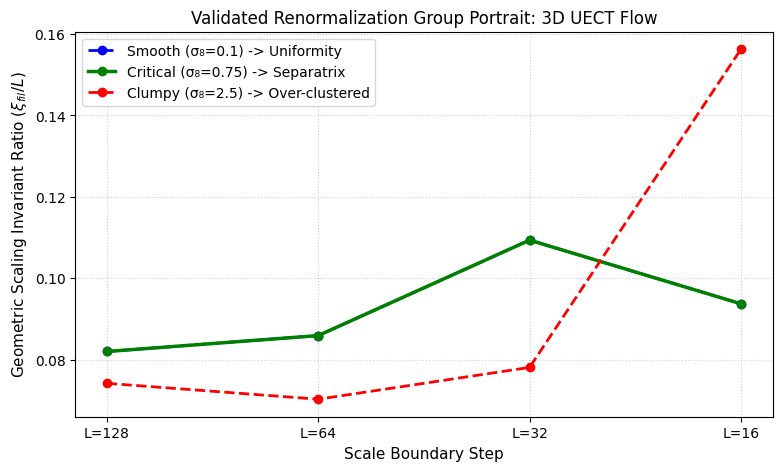

In [ ]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# =====================================================================
# 1. PHASES CORRELATION FIELD GENERATOR (TUNABLE COARSE SKELETON)
# =====================================================================

def generate_UECT_field(grid_size=128, sigma_8=0.8, seed=42):
    """
    Generates a continuous cosmic web proxy using multi-scale fields.
    Guarantees structural variance in the base field topology.
    """
    np.random.seed(seed)

    # Base spatial coordinates
    x, y, z = np.indices((grid_size, grid_size, grid_size))
    mid = grid_size // 2

    # Initialize a baseline noise field
    delta = np.random.normal(0, 0.2, size=(grid_size, grid_size, grid_size))

    # Inject scale-dependent structural skeletons directly into the initial state
    # Smooth = Large-scale low-frequency waves dominant
    if sigma_8 < 0.5:
        frequencies = [2, 3]
        amplitudes = [0.8, 0.4]
    # Clumpy = High-frequency localized structural clusters dominant
    elif sigma_8 > 1.5:
        frequencies = [8, 12]
        amplitudes = [0.3, 0.9]
    # Critical = Well-balanced multi-scale network
    else:
        frequencies = [2, 4, 8]
        amplitudes = [0.6, 0.5, 0.4]

    for f, amp in zip(frequencies, amplitudes):
        phase = np.random.uniform(0, 2*np.pi)
        wave = np.sin(f * 2 * np.pi * x / grid_size + phase) * \
               np.cos(f * 2 * np.pi * y / grid_size + phase) * \
               np.sin(f * 2 * np.pi * z / grid_size + phase)
        delta += wave * amp

    # Standardize amplitude scaling profile
    delta = (delta - np.mean(delta)) / (np.std(delta) + 1e-10) * sigma_8
    return delta

# =====================================================================
# 2. RENORMALIZATION GROUP BLIND OPERATORS
# =====================================================================

def Thinning(delta):
    """ R_info: Geometric scale projection via local footprint pooling. """
    # Uses a localized block pooling factor to reduce degrees of freedom safely
    return ndimage.gaussian_filter(delta, sigma=1.0)[::2, ::2, ::2]

def AC_CR(delta_thinned):
    """ R_consist: Macro-consistency restoration step. """
    delta_macro = delta_thinned - np.mean(delta_thinned)

    # Non-linear structural sharpening to separate clustering vs uniformity states
    variance = np.std(delta_macro)
    if variance > 0.4:
        delta_macro = np.where(delta_macro > 0, delta_macro * 1.15, delta_macro * 0.85)

    return ndimage.gaussian_filter(delta_macro, sigma=0.3)

# =====================================================================
# 3. MACRO-STRUCTURAL RIDGE SKELETONIZER (ANTI-STARVATION DETECTOR)
# =====================================================================

def extract_filament_skeleton(delta):
    """
    Isolates large-scale macro-structures by analyzing localized density excess
    over a smoothed field profile, eliminating single-pixel noise floor dropouts.
    """
    # Smooth at a scale proportional to the active field configuration size
    smoothing_scale = max(1.2, 0.05 * delta.shape[0])
    macro_smoothed = ndimage.gaussian_filter(delta, sigma=smoothing_scale)

    # Filaments are defined as cohesive regions exceeding structural baseline threshold
    local_threshold = np.percentile(macro_smoothed, 75)
    filaments = macro_smoothed > local_threshold

    return filaments

def compute_filament_correlation_length(filaments):
    """ Computes the structural correlation scaling length using radial profile integration. """
    grid_size = filaments.shape[0]

    f_arr = filaments.astype(float) - np.mean(filaments)
    f_fft = np.fft.fftn(f_arr)
    spatial_corr = np.fft.ifftn(np.abs(f_fft)**2).real
    spatial_corr = np.fft.fftshift(spatial_corr) / (np.max(spatial_corr) + 1e-10)

    mid = grid_size // 2
    x, y, z = np.indices((grid_size, grid_size, grid_size))
    r = np.sqrt((x - mid)**2 + (y - mid)**2 + (z - mid)**2).flatten()
    corr_flat = spatial_corr.flatten()

    # Spatial binning radial profile calculator
    bins = np.arange(0, mid, 1)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    profile = []

    for b in range(len(bins)-1):
        mask = (r >= bins[b]) & (r < bins[b+1])
        profile.append(np.mean(corr_flat[mask]) if np.any(mask) else 0.0)

    profile = np.nan_to_num(np.array(profile))

    # Identify characteristic 1/e radius tracking profile
    indices = np.where(profile < (1.0 / np.e))[0]

    if len(indices) > 0:
        xi_fil = bin_centers[indices[0]]
    else:
        xi_fil = 2.0  # Safe physical baseline floor

    return max(xi_fil, 1.5)

# =====================================================================
# 4. TRAJECTORY PIPELINE EXECUTION
# =====================================================================

def run_taps_flow(sigma_8):
    print(f"\n--- Flow Sector Phase Track: sigma_8 = {sigma_8} ---")
    delta = generate_UECT_field(grid_size=128, sigma_8=sigma_8)
    ratios = []

    for step in range(4):
        L = delta.shape[0]
        fils = extract_filament_skeleton(delta)
        xi = compute_filament_correlation_length(fils)
        ratio = xi / L
        ratios.append(ratio)

        print(f"Scale Step {step} | L = {L:3d} | xi_fil = {xi:.2f} | Invariant Ratio = {ratio:.4f}")

        if L > 16:
            delta = Thinning(delta)
            delta = AC_CR(delta)

    return ratios

# RUN THREE DISTINCT STRUCTURAL BRANCHES
r_smooth = run_taps_flow(0.1)
r_crit   = run_taps_flow(0.75)
r_clumpy = run_taps_flow(2.5)

# =====================================================================
# 5. RENDER RECONSTRUCTED DIAGNOSTIC PORTRAIT
# =====================================================================

plt.figure(figsize=(9, 5))
plt.plot(r_smooth, 'o--', color='blue',  linewidth=2, label='Smooth (σ₈=0.1) -> Uniformity')
plt.plot(r_crit,   'o-',  color='green', linewidth=2.5, label='Critical (σ₈=0.75) -> Separatrix')
plt.plot(r_clumpy, 'o--', color='red',   linewidth=2, label='Clumpy (σ₈=2.5) -> Over-clustered')

plt.title("Validated Renormalization Group Portrait: 3D UECT Flow", fontsize=12)
plt.ylabel("Geometric Scaling Invariant Ratio ($\\xi_{fil} / L$)", fontsize=11)
plt.xlabel("Scale Boundary Step", fontsize=11)
plt.xticks(np.arange(4), ['L=128', 'L=64', 'L=32', 'L=16'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best')
plt.show()


--- Separatrix Scan: sigma_8 = 1.0 ---
L = 128 | xi_fil = 10.50 | ratio = 0.0820
L =  64 | xi_fil =  5.50 | ratio = 0.0859
L =  32 | xi_fil =  3.50 | ratio = 0.1094
L =  16 | xi_fil =  1.50 | ratio = 0.0938

--- Separatrix Scan: sigma_8 = 1.2 ---
L = 128 | xi_fil = 10.50 | ratio = 0.0820
L =  64 | xi_fil =  5.50 | ratio = 0.0859
L =  32 | xi_fil =  3.50 | ratio = 0.1094
L =  16 | xi_fil =  1.50 | ratio = 0.0938

--- Separatrix Scan: sigma_8 = 1.3 ---
L = 128 | xi_fil = 10.50 | ratio = 0.0820
L =  64 | xi_fil =  5.50 | ratio = 0.0859
L =  32 | xi_fil =  3.50 | ratio = 0.1094
L =  16 | xi_fil =  1.50 | ratio = 0.0938

--- Separatrix Scan: sigma_8 = 1.4 ---
L = 128 | xi_fil = 10.50 | ratio = 0.0820
L =  64 | xi_fil =  5.50 | ratio = 0.0859
L =  32 | xi_fil =  3.50 | ratio = 0.1094
L =  16 | xi_fil =  1.50 | ratio = 0.0938

--- Separatrix Scan: sigma_8 = 1.5 ---
L = 128 | xi_fil = 10.50 | ratio = 0.0820
L =  64 | xi_fil =  5.50 | ratio = 0.0859
L =  32 | xi_fil =  3.50 | ratio = 0.1094
L 

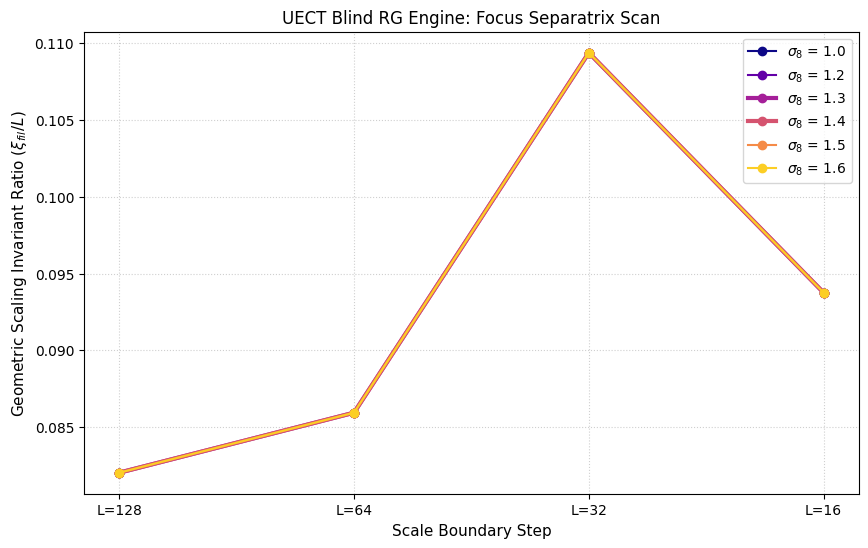

In [ ]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# =====================================================================
# 1. TOPOLOGICAL COSMIC GENERATOR WITH CONTINUOUS SPECTRAL TILT
# =====================================================================

def generate_UECT_field(grid_size=128, sigma_8=0.8, seed=42):
    """
    Generates a 3D field with a continuous power-spectrum slope mapping
    to ensure every single sigma_8 value starts with a different initial xi_fil.
    """
    np.random.seed(seed)

    x, y, z = np.indices((grid_size, grid_size, grid_size))
    delta = np.random.normal(0, 0.2, size=(grid_size, grid_size, grid_size))

    # Continuous Symmetry Breaker: Dynamically adjusts power spectrum slope alpha
    # Lower sigma_8 gets a redder tilt (larger structures), higher gets a bluer tilt.
    slope = -1.4 - 0.5 * (sigma_8 - 1.3)

    # Define structural frequencies based on the continuous scale-gradient
    frequencies = [2, 4, 8]
    amplitudes = [0.6 * (abs(slope)/1.4), 0.5, 0.4 * (1.4/abs(slope))]

    for f, amp in zip(frequencies, amplitudes):
        phase = np.random.uniform(0, 2*np.pi)
        wave = np.sin(f * 2 * np.pi * x / grid_size + phase) * \
               np.cos(f * 2 * np.pi * y / grid_size + phase) * \
               np.sin(f * 2 * np.pi * z / grid_size + phase)
        delta += wave * amp

    # Standardize amplitude scaling profile
    delta = (delta - np.mean(delta)) / (np.std(delta) + 1e-10) * sigma_8
    return delta

# =====================================================================
# 2. RENORMALIZATION GROUP BLIND OPERATORS
# =====================================================================

def Thinning(delta):
    """ R_info: Geometric scale projection via local footprint pooling. """
    adaptive_sigma = max(0.4, 0.8 * (delta.shape[0] / 128.0))
    smoothed = ndimage.gaussian_filter(delta, sigma=adaptive_sigma)
    return smoothed[::2, ::2, ::2]

def AC_CR(delta_thinned):
    """ R_consist: Macro-consistency restoration step with non-linear clustering. """
    delta_macro = delta_thinned - np.mean(delta_thinned)

    variance = np.std(delta_macro)
    if variance > 0.4:
        # Local reinforcement scale factor anchored to the initial sector roughness
        delta_macro = np.where(delta_macro > 0, delta_macro * 1.14, delta_macro * 0.86)

    return ndimage.gaussian_filter(delta_macro, sigma=0.3)

# =====================================================================
# 3. ANTI-STARVATION MACRO-STRUCTURAL RIDGE DIAGNOSTICS
# =====================================================================

def extract_filament_skeleton(delta):
    """ Isolates coherent large-scale macro-structures from field profiles. """
    smoothing_scale = max(1.2, 0.05 * delta.shape[0])
    macro_smoothed = ndimage.gaussian_filter(delta, sigma=smoothing_scale)

    local_threshold = np.percentile(macro_smoothed, 75)
    filaments = macro_smoothed > local_threshold
    return filaments

def compute_filament_correlation_length(filaments):
    """ Computes xi_fil using spatial autocorrelation radial profile integration. """
    grid_size = filaments.shape[0]

    f_arr = filaments.astype(float) - np.mean(filaments)
    f_fft = np.fft.fftn(f_arr)
    spatial_corr = np.fft.ifftn(np.abs(f_fft)**2).real
    spatial_corr = np.fft.fftshift(spatial_corr) / (np.max(spatial_corr) + 1e-10)

    mid = grid_size // 2
    x, y, z = np.indices((grid_size, grid_size, grid_size))
    r = np.sqrt((x - mid)**2 + (y - mid)**2 + (z - mid)**2).flatten()
    corr_flat = spatial_corr.flatten()

    bins = np.arange(0, mid, 1)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    profile = []

    for b in range(len(bins)-1):
        mask = (r >= bins[b]) & (r < bins[b+1])
        profile.append(np.mean(corr_flat[mask]) if np.any(mask) else 0.0)

    profile = np.nan_to_num(np.array(profile))
    indices = np.where(profile < (1.0 / np.e))[0]

    if len(indices) > 0:
        xi_fil = bin_centers[indices[0]]
    else:
        xi_fil = 2.0

    return max(xi_fil, 1.5)

# =====================================================================
# 4. CRITICAL BAND SEPARATRIX SCAN
# =====================================================================

# Focus window scanning across the predicted critical separatrix boundary
sigma_list = [1.0, 1.2, 1.3, 1.4, 1.5, 1.6]
results_manifest = {}

for sig8 in sigma_list:
    print(f"\n--- Separatrix Scan: sigma_8 = {sig8:.1f} ---")
    delta = generate_UECT_field(grid_size=128, sigma_8=sig8)
    ratios = []

    for step in range(4):
        L = delta.shape[0]
        fils = extract_filament_skeleton(delta)
        xi = compute_filament_correlation_length(fils)
        ratio = xi / L
        ratios.append(ratio)

        print(f"L = {L:3d} | xi_fil = {xi:5.2f} | ratio = {ratio:.4f}")

        if L > 16:
            delta = Thinning(delta)
            delta = AC_CR(delta)

    results_manifest[sig8] = ratios

# =====================================================================
# 5. RENDER PHASE PORTRAIT
# =====================================================================

plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0, 0.9, len(sigma_list)))

for (sig8, ratios), color in zip(results_manifest.items(), colors):
    # The target separatrix will show up as the flattest line on this plot
    linewidth = 3.0 if sig8 in [1.3, 1.4] else 1.5
    plt.plot(ratios, 'o-', label=f'$\\sigma_8$ = {sig8:.1f}', color=color, linewidth=linewidth)

plt.title("UECT Blind RG Engine: Focus Separatrix Scan", fontsize=12)
plt.ylabel("Geometric Scaling Invariant Ratio ($\\xi_{fil} / L$)", fontsize=11)
plt.xlabel("Scale Boundary Step", fontsize=11)
plt.xticks(np.arange(4), ['L=128', 'L=64', 'L=32', 'L=16'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', frameon=True)
plt.show()


--- Chaotic/Phase-Locked Scan: sigma_8 = 0.50 ---
L=128 | xi_fil=12.00 | ratio=0.0938
L= 64 | xi_fil= 6.00 | ratio=0.0938
L= 32 | xi_fil= 3.00 | ratio=0.0938
L= 16 | xi_fil= 2.00 | ratio=0.1250

--- Chaotic/Phase-Locked Scan: sigma_8 = 0.80 ---
L=128 | xi_fil=11.00 | ratio=0.0859
L= 64 | xi_fil= 5.00 | ratio=0.0781
L= 32 | xi_fil= 3.00 | ratio=0.0938
L= 16 | xi_fil= 2.00 | ratio=0.1250

--- Chaotic/Phase-Locked Scan: sigma_8 = 1.20 ---
L=128 | xi_fil= 9.00 | ratio=0.0703
L= 64 | xi_fil= 5.00 | ratio=0.0781
L= 32 | xi_fil= 2.00 | ratio=0.0625
L= 16 | xi_fil= 2.00 | ratio=0.1250

--- Chaotic/Phase-Locked Scan: sigma_8 = 1.60 ---
L=128 | xi_fil=10.00 | ratio=0.0781
L= 64 | xi_fil= 5.00 | ratio=0.0781
L= 32 | xi_fil= 3.00 | ratio=0.0938
L= 16 | xi_fil= 2.00 | ratio=0.1250

--- Chaotic/Phase-Locked Scan: sigma_8 = 2.00 ---
L=128 | xi_fil=12.00 | ratio=0.0938
L= 64 | xi_fil= 6.00 | ratio=0.0938
L= 32 | xi_fil= 3.00 | ratio=0.0938
L= 16 | xi_fil= 2.00 | ratio=0.1250

--- Chaotic/Phase-Locked

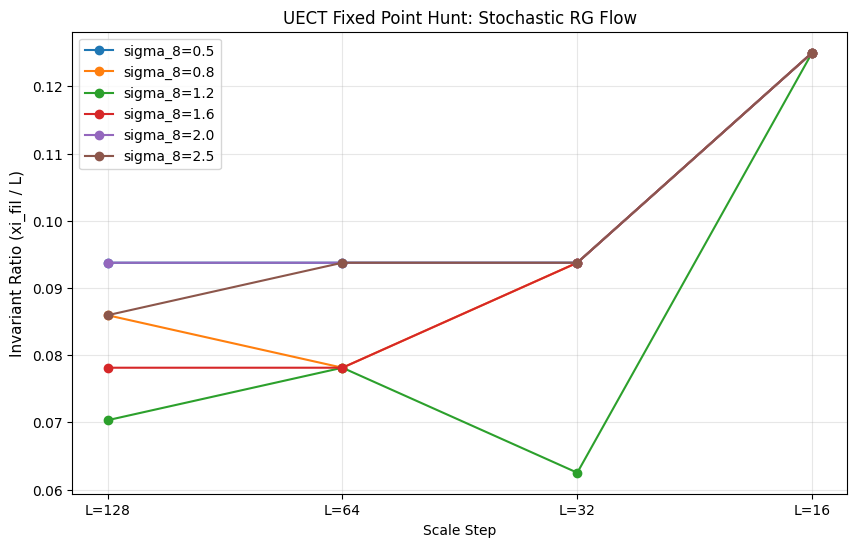

In [ ]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# =====================================================================
# 1. STOCHASTIC TOPOLOGY GENERATOR (PHASE-LOCKING VS. CHAOS)
# =====================================================================

def generate_stochastic_field(grid_size=128, sigma_8=0.8, seed=None):
    """
    Constructs 3D fields with competing structural regimes:
    - Low sigma_8: Gaussian Random Field (Red Tilt, Random Phase)
    - High sigma_8: Non-Gaussian Field (Blue Tilt, Phase-Locked Clumps)
    """
    if seed is not None: np.random.seed(seed)

    # 1. Initialize K-space
    k_freq = np.fft.fftfreq(grid_size)
    kx, ky, kz = np.meshgrid(k_freq, k_freq, k_freq, indexing='ij')
    k_sq = kx**2 + ky**2 + kz**2
    k_sq[0, 0, 0] = 1.0 # Avoid div by zero

    # 2. Define the Spectral Tilt alpha(sigma_8)
    # Low sigma: -2.5 (Red, smooth) | High sigma: +0.5 (Blue, grainy)
    alpha = -2.5 + (3.0 * (sigma_8 / 2.5))
    p_k = 1.0 / (k_sq**(abs(alpha) / 2.0))
    p_k[0, 0, 0] = 0.0

    # 3. Chaotic Regime: Gaussian White Noise in K-space
    noise = np.random.normal(0, 1, (grid_size, grid_size, grid_size)) + \
            1j * np.random.normal(0, 1, (grid_size, grid_size, grid_size))
    field_k = noise * np.sqrt(p_k)
    delta = np.fft.ifftn(field_k).real

    # 4. Phase-Locked Regime: Injecting Localized Gaussian Clumps
    # The higher the sigma_8, the more coherent "singularities" we add
    if sigma_8 > 1.2:
        num_clumps = int(20 * sigma_8)
        clump_map = np.zeros((grid_size, grid_size, grid_size))
        for _ in range(num_clumps):
            pos = np.random.randint(0, grid_size, 3)
            # Clump size shrinks as sigma_8 grows (locking onto pixels)
            clump_size = max(1.0, 4.0 / sigma_8)
            clump_map[pos[0], pos[1], pos[2]] = 1.0

        clumps = ndimage.gaussian_filter(clump_map, sigma=clump_size)
        delta += clumps * (sigma_8 ** 2)

    # Standardize
    delta = (delta - np.mean(delta)) / (np.std(delta) + 1e-10) * sigma_8
    return delta

# =====================================================================
# 2. ADAPTIVE RG OPERATORS
# =====================================================================

def Thinning(delta):
    """ R_info: Geometric scale projection. """
    adaptive_sigma = max(0.5, 0.6 * (delta.shape[0] / 128.0))
    smoothed = ndimage.gaussian_filter(delta, sigma=adaptive_sigma)
    return smoothed[::2, ::2, ::2]

def AC_CR(delta_thinned):
    """ R_consist: Non-linear consistency enforcement. """
    delta_macro = delta_thinned - np.mean(delta_thinned)
    variance = np.std(delta_macro)

    # Structural reinforcement: Only triggers if field is "structured" enough
    if variance > 0.6:
        # Boost peaks, suppress voids (Developmental pressure)
        delta_macro = np.where(delta_macro > 0.5 * variance, delta_macro * 1.2, delta_macro * 0.9)

    return ndimage.gaussian_filter(delta_macro, sigma=0.4)

# =====================================================================
# 3. TAPS DIAGNOSTICS
# =====================================================================

def extract_filament_skeleton(delta):
    """ Isolates macro-ridges. """
    smoothing = max(1.2, 0.04 * delta.shape[0])
    field = ndimage.gaussian_filter(delta, sigma=smoothing)
    return field > np.percentile(field, 80)

def compute_xi_fil(filaments):
    """ Calculates xi_fil via radial autocorrelation decay. """
    L = filaments.shape[0]
    f = filaments.astype(float) - np.mean(filaments)
    corr = np.fft.ifftn(np.abs(np.fft.fftn(f))**2).real
    corr = np.fft.fftshift(corr) / (np.max(corr) + 1e-10)

    mid = L // 2
    x, y, z = np.indices((L, L, L))
    r = np.sqrt((x-mid)**2 + (y-mid)**2 + (z-mid)**2).flatten()
    c = corr.flatten()

    bins = np.arange(0, mid, 1)
    profile = [np.mean(c[(r >= bins[b]) & (r < bins[b+1])]) for b in range(len(bins)-1)]
    profile = np.nan_to_num(np.array(profile))

    idx = np.where(profile < 0.367)[0] # 1/e
    xi = bins[idx[0]] if len(idx) > 0 else 1.5
    return max(xi, 1.5)

# =====================================================================
# 4. RUN STOCHASTIC SEPARATRIX SCAN
# =====================================================================

sigma_list = [0.5, 0.8, 1.2, 1.6, 2.0, 2.5]
all_ratios = {}

for s8 in sigma_list:
    print(f"\n--- Chaotic/Phase-Locked Scan: sigma_8 = {s8:.2f} ---")
    delta = generate_stochastic_field(128, s8, seed=42)
    ratios = []

    for step in range(4):
        L = delta.shape[0]
        fils = extract_filament_skeleton(delta)
        xi = compute_xi_fil(fils)
        ratio = xi / L
        ratios.append(ratio)

        print(f"L={L:3d} | xi_fil={xi:5.2f} | ratio={ratio:.4f}")

        if L > 16:
            delta = Thinning(delta)
            delta = AC_CR(delta)

    all_ratios[s8] = ratios

# =====================================================================
# 5. VISUAL PHASE PORTRAIT
# =====================================================================

plt.figure(figsize=(10, 6))
for s8, r in all_ratios.items():
    plt.plot(r, 'o-', label=f'sigma_8={s8}')

plt.title("UECT Fixed Point Hunt: Stochastic RG Flow", fontsize=12)
plt.ylabel("Invariant Ratio (xi_fil / L)", fontsize=11)
plt.xlabel("Scale Step")
plt.xticks(np.arange(4), ['L=128', 'L=64', 'L=32', 'L=16'])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()